<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/ResumeJobmatching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
pip install transformers datasets torch accelerate


In [14]:
pip install scikit-learn gensim


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
# nlp
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from gensim.models import Word2Vec



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB


from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [16]:
from transformers import DistilBertTokenizerFast
from transformers import DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch
import pandas as pd

In [17]:
from google.colab import files

In [12]:
uploaded=files.upload()

Saving archive.zip to archive.zip


In [18]:
import zipfile
with zipfile.ZipFile('archive.zip', 'r') as z:
    z.extractall('resume_dataset')

In [19]:
# check the folder structure
import os
for  root,dirs,fs in os.walk('resume_dataset'):
  print(root, '->', fs[:3], f"...({len(fs)} files)" if len(fs) > 3 else "")

resume_dataset -> [] 
resume_dataset/Resume -> ['Resume.csv'] 
resume_dataset/data -> [] 
resume_dataset/data/data -> [] 
resume_dataset/data/data/SALES -> ['85918100.pdf', '26994282.pdf', '17704246.pdf'] ...(116 files)
resume_dataset/data/data/HEALTHCARE -> ['20835760.pdf', '98300955.pdf', '10251432.pdf'] ...(115 files)
resume_dataset/data/data/ENGINEERING -> ['38535335.pdf', '86209934.pdf', '39855211.pdf'] ...(118 files)
resume_dataset/data/data/HR -> ['26289308.pdf', '28828844.pdf', '13520837.pdf'] ...(110 files)
resume_dataset/data/data/DIGITAL-MEDIA -> ['10515955.pdf', '81508860.pdf', '37739183.pdf'] ...(96 files)
resume_dataset/data/data/AVIATION -> ['14790629.pdf', '29534737.pdf', '50775901.pdf'] ...(117 files)
resume_dataset/data/data/AGRICULTURE -> ['29510501.pdf', '18242317.pdf', '29142288.pdf'] ...(63 files)
resume_dataset/data/data/ADVOCATE -> ['49475708.pdf', '18725071.pdf', '20765795.pdf'] ...(118 files)
resume_dataset/data/data/ACCOUNTANT -> ['14449423.pdf', '15289348.pd

In [20]:

resume_df=pd.read_csv('/content/resume_dataset/Resume/Resume.csv')


**EDA**

In [21]:
resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [22]:
print(resume_df.columns.tolist())

['ID', 'Resume_str', 'Resume_html', 'Category']


In [23]:
resume_df.shape

(2484, 4)

In [24]:
resume_df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [25]:
print(resume_df['Category'].value_counts())
print(resume_df.info())


Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str 

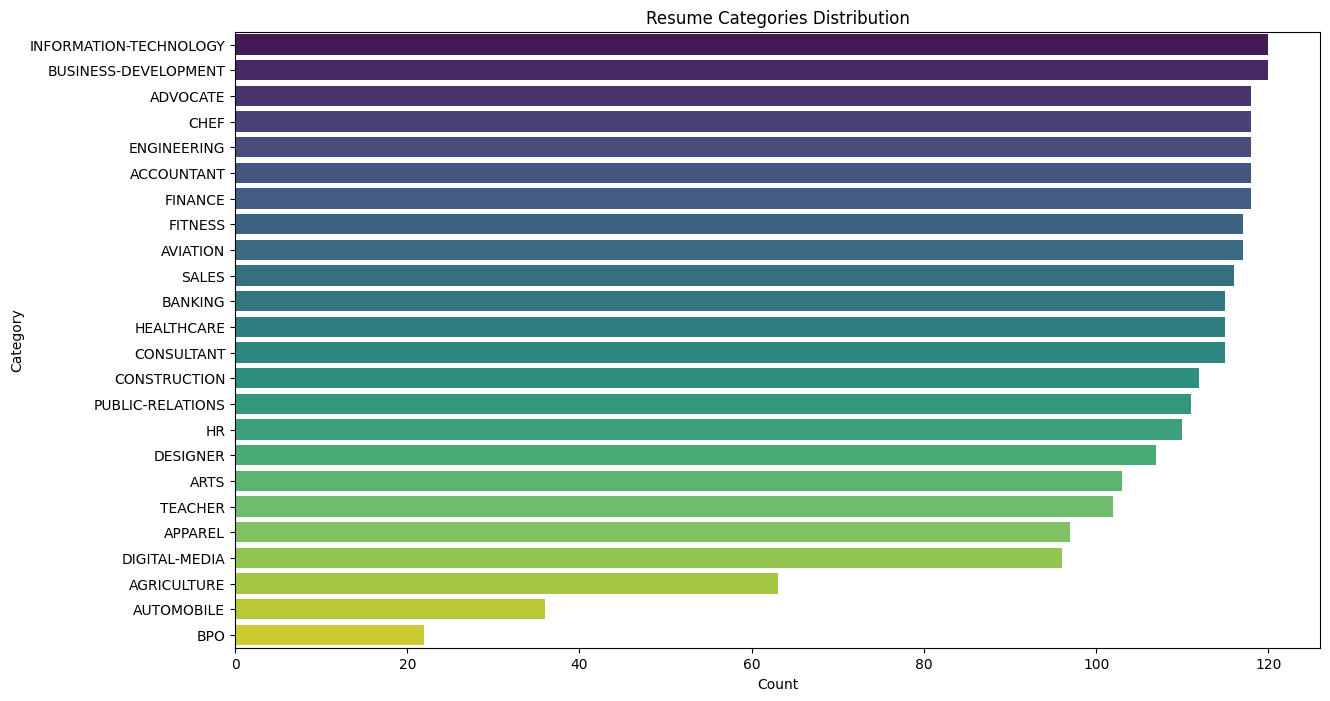

In [26]:
plt.figure(figsize=(14,8))

sns.countplot(
    y=resume_df['Category'],
    order=resume_df['Category'].value_counts().index,
    palette='viridis'
)

plt.title('Resume Categories Distribution')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

<Figure size 1400x800 with 0 Axes>

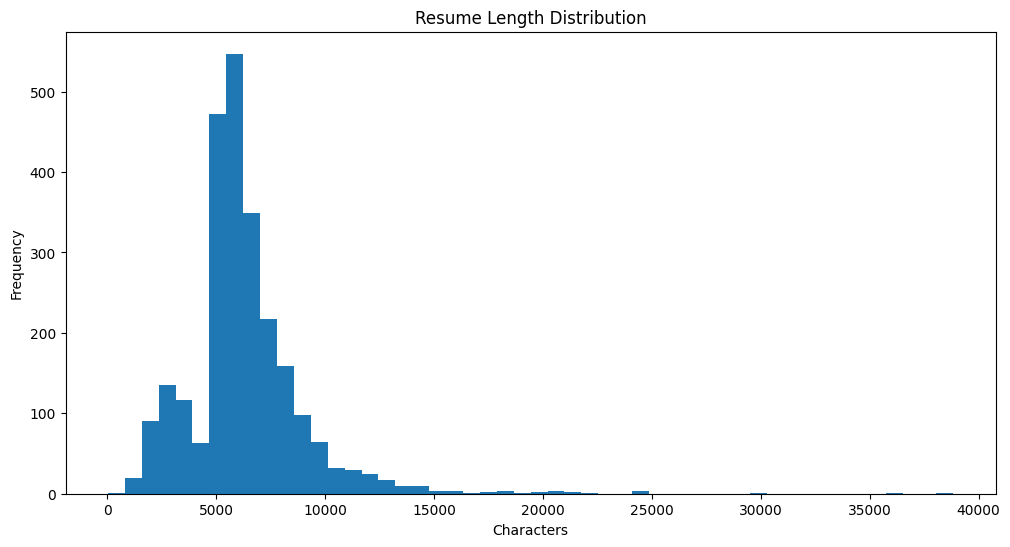

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: resume_length, dtype: float64


In [27]:
resume_df['resume_length'] = resume_df['Resume_str'].apply(len)

plt.figure(figsize=(14,8))


plt.figure(figsize=(12,6))
plt.hist(resume_df['resume_length'], bins=50)
plt.title('Resume Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.show()

print(resume_df['resume_length'].describe())

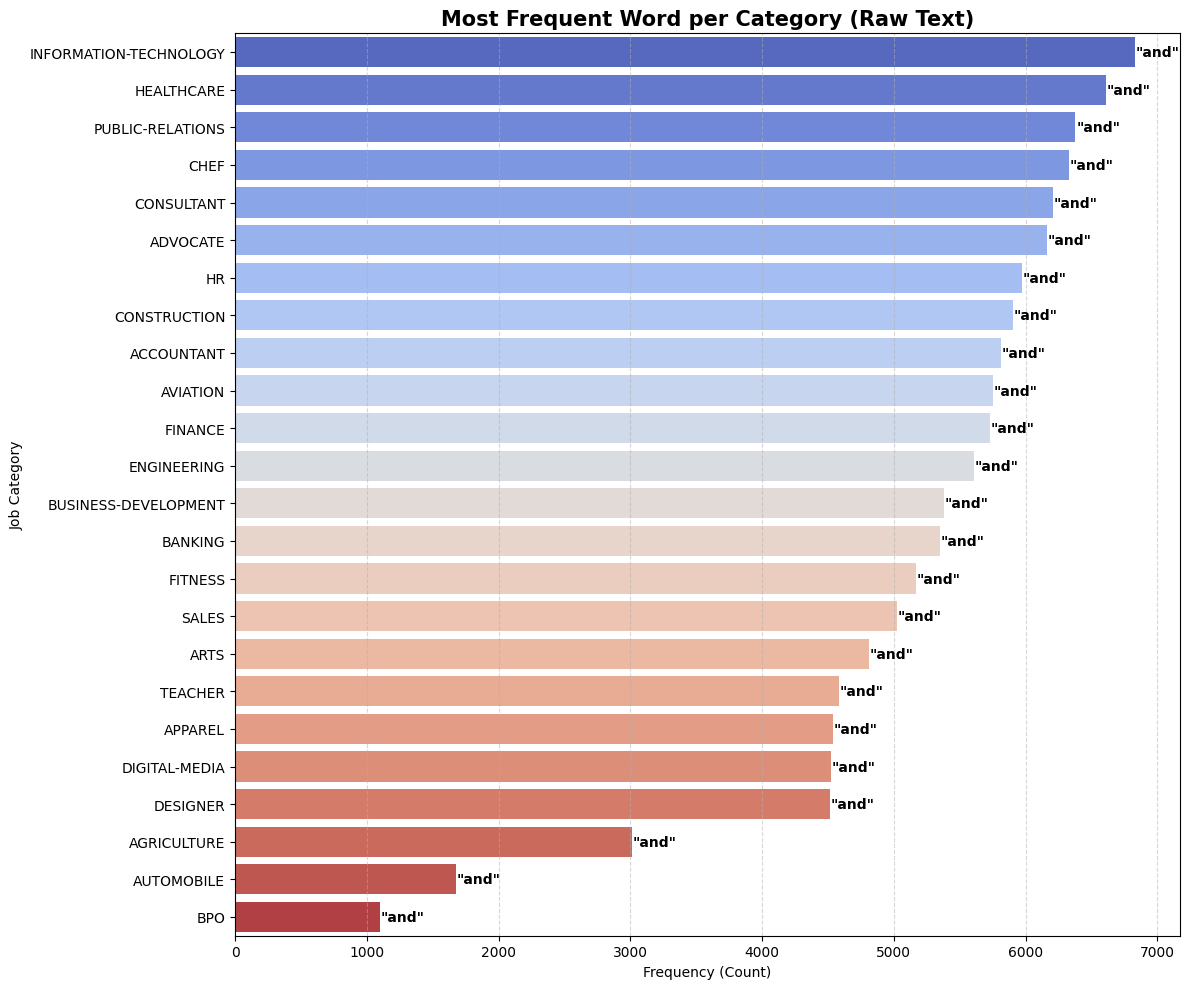

                  Category Top_Word  Count
2   INFORMATION-TECHNOLOGY      and   6827
6               HEALTHCARE      and   6607
20        PUBLIC-RELATIONS      and   6378
14                    CHEF      and   6332
11              CONSULTANT      and   6206
4                 ADVOCATE      and   6164
0                       HR      and   5974
19            CONSTRUCTION      and   5906
18              ACCOUNTANT      and   5816
23                AVIATION      and   5755
15                 FINANCE      and   5729
17             ENGINEERING      and   5607
5     BUSINESS-DEVELOPMENT      and   5380
21                 BANKING      and   5347
7                  FITNESS      and   5168
10                   SALES      and   5020
22                    ARTS      and   4812
3                  TEACHER      and   4581
16                 APPAREL      and   4541
12           DIGITAL-MEDIA      and   4520
1                 DESIGNER      and   4513
8              AGRICULTURE      and   3015
13         

In [28]:
from collections import Counter


# 1. Logic to find the most frequent word per category
results = []
categories = resume_df['Category'].unique()

for cat in categories:
    # Combine all raw text for this specific category
    raw_text = " ".join(resume_df[resume_df['Category'] == cat]['Resume_str'].astype(str)).lower().split()

    # Optional: Filter out words with 2 or fewer characters to avoid 'a', 'to', 'of'
    filtered_words = [w for w in raw_text if len(w) > 2 ]

    if filtered_words:
        top_word, count = Counter(filtered_words).most_common(1)[0]
        results.append({'Category': cat, 'Top_Word': top_word, 'Count': count})

top_words_df = pd.DataFrame(results).sort_values(by='Count', ascending=False)

# 2. Visualization
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='Count', y='Category', data=top_words_df, palette='coolwarm')

# 3. Annotate the bars with the actual word
for i, (count, word) in enumerate(zip(top_words_df['Count'], top_words_df['Top_Word'])):
    ax.text(count + 5, i, f'"{word}"', va='center', fontweight='bold', color='black')

plt.title('Most Frequent Word per Category (Raw Text)', fontsize=15, fontweight='bold')
plt.xlabel('Frequency (Count)')
plt.ylabel('Job Category')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Print the table for reference
print(top_words_df)

Text preprocessing

In [29]:
resume_df

,ID,Resume_str,Resume_html,Category,resume_length
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,5442
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,5572
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,7720
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,2855
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,9172
...,...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,5533
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION,7108
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,2020
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,5074


In [30]:
resume_df.drop(columns=['ID', 'Resume_html'], inplace=True)


In [31]:
# STOPWORDS = set(stopwords.words('english'))
# lemmatizer = WordNetLemmatizer()


# def clean_text(text):
#     # lower case
#     text=text.lower()

#     # remove url and links
#     text = re.sub(r'http\S+|www\S+', ' ', text)

#     # remove email
#     text = re.sub(r'\S+@\S+', ' ', text)

#     # remove special characters
#     text = re.sub(r'[^\w\s]', ' ', text)

#     # remove html
#     text = re.sub(r'<.*?>', ' ', text)

#     # remove numbers
#     text = re.sub(r'\d+', ' ', text)

#     # Keeps only alphabets and spaces
#     text = re.sub(r'[^a-zA-Z\s]', ' ', text)

#     # tokenization
#     tokens = word_tokenize(text)

#     # remove stopwords
#     # lemenization
#     # Only keeps words longer than 2 characters to filter out noise
#     tokens = [
#         lemmatizer.lemmatize(word)
#         for word in tokens
#         if word not in STOPWORDS and len(word) > 2
#     ]

#     # 9. Re-join and remove redundant whitespaces
#     text = ' '.join(tokens)
#     text = re.sub(r'\s+', ' ', text).strip()

#     return text
# print("cleaning text")
# resume_df['clean_text'] = resume_df['Resume_str'].apply(clean_text)
# # Inspect the transformation
# print(resume_df[['Resume_str', 'clean_text']].head())








Feature Enginnering

In [32]:
print(resume_df['Category'])

0             HR
1             HR
2             HR
3             HR
4             HR
          ...   
2479    AVIATION
2480    AVIATION
2481    AVIATION
2482    AVIATION
2483    AVIATION
Name: Category, Length: 2484, dtype: object


In [33]:
# tfidf=TfidfVectorizer(
#     max_features=5000,
#     min_df=2,
#     max_df=0.9,
#     ngram_range=(1,2),stop_words='english')

# X_tfidf=tfidf.fit_transform(resume_df['clean_text'])

# tfidf_ngram = TfidfVectorizer(
#     max_features=7000,
#     ngram_range=(1,2),
#     min_df=2,
#     max_df=0.9
# )
# X_ngram = tfidf_ngram.fit_transform(resume_df['clean_text'])


# tokenized_text = resume_df['clean_text'].apply(lambda x: x.split())

# # world2vec training
# word2vec_model=Word2Vec(
#     sentences=tokenized_text,
#     vector_size=100,
#     window=5,
#     min_count=1,
#     sg=0,
#     workers=4
# )

# le=LabelEncoder()
# y=le.fit_transform(resume_df['Category'])

# print("Label Encoder Classes:", le.classes_)

# print("\nWord2Vec Model Trained Successfully!")

# print("\nVector for word 'python':")
# print(word2vec_model.wv['python'][:10])

# print("\nWords similar to 'python':")
# print(word2vec_model.wv.most_similar('python')[:5])




Data Spliting(Train/test splt)

In [34]:
# X_train,X_test,y_train,y_test=train_test_split(
#     X_ngram,
#     y,
#     test_size=0.2,
#     random_state=42
# )
# print("X_train shape:", X_train.shape)
# print("X_test shape:", X_test.shape)
# print("y_train shape:", y_train.shape)
# print("y_test shape:", y_test.shape)


machine learning model

In [35]:
# svm_model=LinearSVC(
#     C=1,
#     class_weight='balanced',
#     random_state=42
# )
# log_model=LogisticRegression(
#     C=1,
#     class_weight='balanced',
#     random_state=42
# )
# nb_model=MultinomialNB()

model training

In [36]:
# print("Svm training")
# svm_model.fit(X_train,y_train)
# y_predict_svm=svm_model.predict(X_test)
# print(f"\nSVM Accuracy: {accuracy_score(y_test, y_predict_svm) * 100:.2f}%")
# print(classification_report(y_test, y_predict_svm, target_names=le.classes_))

# print("SVM finished")
# print("Logistic Regression training")
# log_model.fit(X_train,y_train)
# y_predict_log=log_model.predict(X_test)
# print(f"\nLogistic Regression Accuracy: {accuracy_score(y_test, y_predict_log) * 100:.2f}%")
# print(classification_report(y_test, y_predict_log, target_names=le.classes_))
# print("Logistic Regression finished")
# print("Naive Bayes training")
# nb_model.fit(X_train,y_train)
# y_predict_nb=nb_model.predict(X_test)
# print(f"\nNaive Bayes Accuracy: {accuracy_score(y_test, y_predict_nb) * 100:.2f}%")
# print("Naive Bayes finished")
# #classification report
# print(classification_report(y_test, y_predict_nb, target_names=le.classes_))


# **using transformer**

In [37]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [38]:
le = LabelEncoder()
resume_df['encoded_category'] = le.fit_transform(resume_df['Category'])

In [39]:
resume_df

,Resume_str,Category,resume_length,encoded_category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,5442,19
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,5572,19
2,HR DIRECTOR Summary Over 2...,HR,7720,19
3,HR SPECIALIST Summary Dedica...,HR,2855,19
4,HR MANAGER Skill Highlights ...,HR,9172,19
...,...,...,...,...
2479,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION,5533,6
2480,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION,7108,6
2481,GEEK SQUAD AGENT Professional...,AVIATION,2020,6
2482,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION,5074,6


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    resume_df['Resume_str'],
    resume_df['encoded_category'],
    test_size=0.2,
    random_state=42
)

In [41]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [42]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True
)

In [43]:
class ResumeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [44]:
train_dataset=ResumeDataset(train_encodings, y_train.tolist())
test_dataset=ResumeDataset(test_encodings, y_test.tolist())

In [45]:
model=DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(le.classes_)
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
)

In [47]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

In [48]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,0.995846
2,No log,0.665896
3,1.440975,0.641954


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=747, training_loss=1.1245374258263523, metrics={'train_runtime': 374.7711, 'train_samples_per_second': 15.906, 'train_steps_per_second': 1.993, 'total_flos': 789947969052672.0, 'train_loss': 1.1245374258263523, 'epoch': 3.0})

In [50]:
model.save_pretrained('./resume_classifier_model')
tokenizer.save_pretrained('./resume_classifier_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./resume_classifier_model/tokenizer_config.json',
 './resume_classifier_model/tokenizer.json')

In [51]:
predection=trainer.predict(test_dataset)

In [52]:
y_pred=np.argmax(predection.predictions, axis=1)

In [53]:
accuracy=accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 85.11%
                        precision    recall  f1-score   support

            ACCOUNTANT       1.00      1.00      1.00        29
              ADVOCATE       0.78      0.83      0.81        30
           AGRICULTURE       0.71      0.62      0.67         8
               APPAREL       0.56      0.50      0.53        20
                  ARTS       0.42      0.44      0.43        18
            AUTOMOBILE       0.00      0.00      0.00         6
              AVIATION       0.74      0.81      0.77        21
               BANKING       0.94      0.74      0.83        23
                   BPO       0.00      0.00      0.00         2
  BUSINESS-DEVELOPMENT       1.00      1.00      1.00        27
                  CHEF       0.87      0.83      0.85        24
          CONSTRUCTION       0.94      1.00      0.97        34
            CONSULTANT       0.94      0.85      0.89        20
              DESIGNER       0.86      1.00      0.93        19
         DIGITAL-MEDIA

<function matplotlib.pyplot.show(close=None, block=None)>

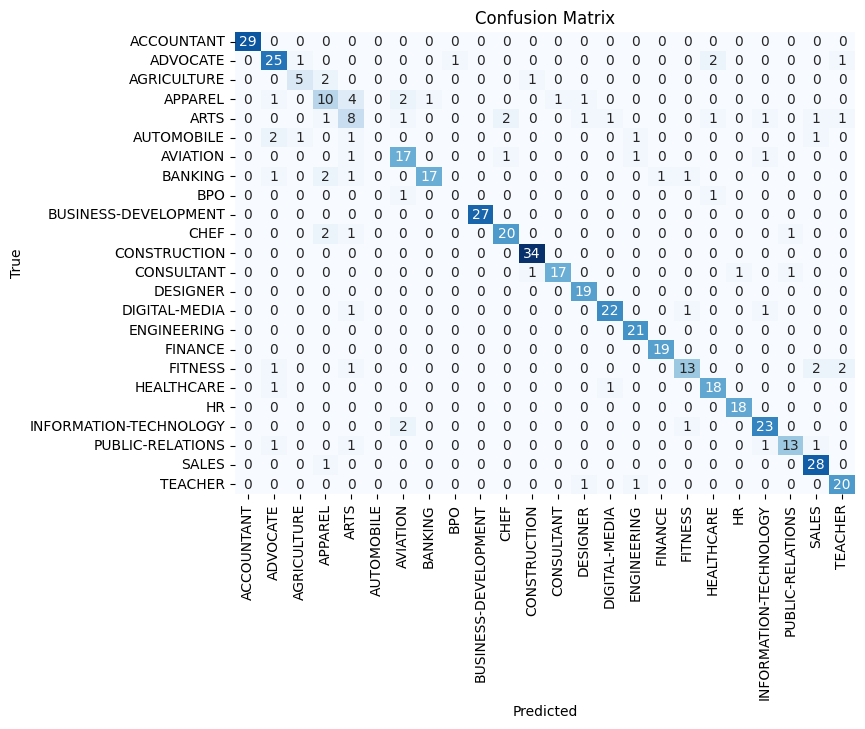

In [54]:
cn=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show

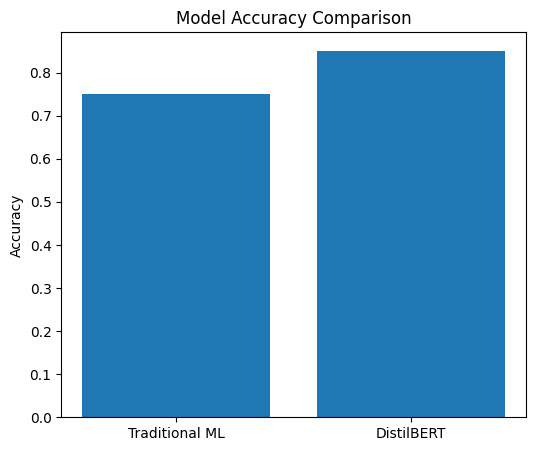

In [56]:
models = ['Traditional ML', 'DistilBERT']
accuracies = [0.75, accuracy]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()